# Modélisation

## Data Import

In [3]:
import pandas as pd
import numpy as np

# 1. Charger le CSV
df = pd.read_csv('../data/avis_cleaned.csv', sep=';')

df.head()

,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",A day ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
1,Patrice,5,Comportement professionnel,Comportement professionnel,"February 11, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
3,Derek Mcmillan,5,Excellent.,Excellent.,"February 4, 2026","Feb 4, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 5, 2026","Bonjour Derek, Je vous remercie pour votre ret..."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre..."


## Text Cleaning avec Spacy

In [2]:
import pandas as pd
import spacy

# Chargement du modèle français
# (Nécessite: python -m spacy download fr_core_news_sm)
nlp = spacy.load("fr_core_news_sm")

# Version optimisée avec nlp.pipe
def nettoyer_rapide(textes):
    docs = nlp.pipe([str(t).lower() for t in textes], disable=["ner", "parser"], n_process=-1)
    clean_texts = []
    for doc in docs:
        tokens = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct and len(t.text) > 2]
        clean_texts.append(" ".join(tokens))
    return clean_texts

df['avis_spacy'] = nettoyer_rapide(df['commentaire'].tolist())
# Application sur votre colonne d'avis (ex: 'avis_text')
# Note: Sur 40 000 lignes, cela peut prendre quelques minutes

In [3]:
df.head()

,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply,commentaire_nltk,avis_spacy
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",A day ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN,produit conforme description contenue ambiguë ...,produit conforme description contenue ambigu f...
1,Patrice,5,Comportement professionnel,Comportement professionnel,"February 11, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN,comportement professionnel,comportement professionnel
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN,ras,r.a.s
3,Derek Mcmillan,5,Excellent.,Excellent.,"February 4, 2026","Feb 4, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 5, 2026","Bonjour Derek, Je vous remercie pour votre ret...",excellent,excellent
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre...",tres bien attention bien scotcher colis derniè...,bien attention bien scotcher colis dernièremen...


## Entraînement et Classification de Thèmes avec BERTopic

In [4]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# Configuration de UMAP (Réduction de dimension)
umap_model = UMAP(n_neighbors=15,
                  n_components=5,
                  min_dist=0.0,
                  metric='cosine',
                  random_state=42)

# Configuration de HDBSCAN (Le moteur de clustering)
# min_cluster_size : taille minimale pour qu'un groupe soit considéré comme un "thème"
hdbscan_model = HDBSCAN(
    min_cluster_size=30, 
    metric='euclidean', 
    cluster_selection_method='eom', 
    prediction_data=True
)

# Initialisation de BERTopic avec les modèles UMAP et HDBSCAN configurés
# Le modèle 'paraphrase-multilingual-MiniLM-L12-v2' est excellent pour le français
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    nr_topics="auto", # 
    verbose=True
)
# 2. Entraînement sur les avis nettoyés
# On utilise la colonne originale ou nettoyée selon vos tests
topics, probs = topic_model.fit_transform(df['avis_spacy'].tolist())

# 3. Voir les sujets principaux découverts
print(topic_model.get_topic_info())

/opt/anaconda3/envs/TrustPilot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-20 14:44:15,841 - BERTopic - Embedding - Transforming documents to embeddings.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9995.53it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1250/1250 [00:21<00:00, 57.18it/s] 
2026-04-20 14:44:40,605 - BERTopic - Embedding - Completed ✓
2026-04-20 14:44:40,605 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: o

     Topic  Count                                           Name  \
0       -1  11690              -1_commande_livraison_jour_oscaro   
1        0   3237      0_véhicule_immatriculation_voiture_plaque   
2        1   2205             1_emballage_carton_colis_plaquette   
3        2   1741                  2_temps_délai_heure_respecter   
4        3   1551                3_site_facile_clair_utilisation   
..     ...    ...                                            ...   
146    145     31  145_écoute_professionnel_compétent_ppersonnel   
147    146     30                   146_qualité_rapport_prix_top   
148    147     30           147_expédition_trop_long_préparation   
149    148     30                  148_rien_accord_redire_jamais   
150    149     30          149_radiateur_antenne_autoradio_abîmé   

                                        Representation  \
0    [commande, livraison, jour, oscaro, colis, piè...   
1    [véhicule, immatriculation, voiture, plaque, c...   
2    [emb

### Sauvegarde

In [5]:
# 1. Sauvegarde du modèle BERTopic
topic_model.save("modele_bertopic_full", serialization="safetensors", save_ctfidf=True)

# 2. Sauvegarde des résultats dans ton CSV
df['topic_id'] = topics
df.to_csv('avis_40k_final_avec_topics.csv', index=False, sep=';')

print("Sauvegarde terminée ! Le modèle et les résultats sont prêts pour l'analyse et l'application.")

Sauvegarde terminée ! Le modèle et les résultats sont prêts pour l'analyse et l'application.


## Visualisation

### Distance Sémantique des thèmes

In [6]:
# Affiche l'interactivité des thèmes (distance sémantique)
topic_model.visualize_topics()

### Hierarchie des thèmes

In [8]:
# 1. Visualisez d'abord la hiérarchie pour comprendre les regroupements naturels
hierarchical_topics = topic_model.hierarchical_topics(df['avis_spacy'].tolist())
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 149/149 [00:00<00:00, 805.49it/s]


### Reduction du nombre de thèmes

In [9]:
# --- MODIFIEZ LE NOMBRE DE THEMES ICI ---
NB_THEMES = 9
# -------------------------------

# --- ÉTAPE DE NETTOYAGE CRITIQUE ---
# On réinitialise les probabilités pour éviter l'IndexError lors de la fusion
topic_model.probabilities_ = None

# 1. Réduction du nombre de thèmes
topic_model.reduce_topics(df['avis_spacy'].tolist(), nr_topics=NB_THEMES)

# --- 2. CALCUL DES PROBABILITÉS ALIGNÉES  ---
# On demande au modèle de recalculer les scores sur la base du nouveau découpage
topics, probs = topic_model.transform(df['avis_spacy'].tolist())
# On met à jour le DataFrame
df['topic_id'] = topics

# Affichage rapide pour vérification
print(f"Nouveau découpage en {NB_THEMES} thèmes terminé.")
print(topic_model.get_topic_info().head(NB_THEMES + 1))

2026-04-20 14:47:07,852 - BERTopic - Topic reduction - Reducing number of topics
2026-04-20 14:47:07,867 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 14:47:07,970 - BERTopic - Representation - Completed ✓
2026-04-20 14:47:07,971 - BERTopic - Topic reduction - Reduced number of topics from 151 to 9
Batches: 100%|██████████| 1250/1250 [00:19<00:00, 65.09it/s] 
2026-04-20 14:47:27,287 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-20 14:47:27,354 - BERTopic - Dimensionality - Completed ✓
2026-04-20 14:47:27,354 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-20 14:47:28,036 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-04-20 14:48:05,087 - BERTopic - Probabilities - Completed ✓
2026-04-20 14:48:05,087 - BERTopic - Cluster - Completed ✓


Nouveau découpage en 9 thèmes terminé.
   Topic  Count                                        Name  \
0     -1  11690          -1_livraison_commande_pièce_rapide   
1      0  16671        0_livraison_rapide_commande_conforme   
2      1   7422           1_véhicule_pièce_emballage_carton   
3      2   2692                    2_bien_parfaire_bon_rien   
4      3    587                 3_long_trop_délai_livraison   
5      4    450            4_photo_conforme_produit_couleur   
6      5    365           5_nickel_livraison_rapide_produit   
7      6     67                6_amazon_jour_livraison_long   
8      7     36  7_installer_facile_installation_rapidement   

                                      Representation  \
0  [livraison, commande, pièce, rapide, colis, pr...   
1  [livraison, rapide, commande, conforme, prix, ...   
2  [véhicule, pièce, emballage, carton, immatricu...   
3  [bien, parfaire, bon, rien, satisfait, produit...   
4  [long, trop, délai, livraison, préparation, be.

In [10]:
# 1. Le Barchart des 10 thèmes
# On précise n_words=10 pour voir les 10 mots les plus représentatifs de chaque grand thème
fig_bar = topic_model.visualize_barchart(top_n_topics=10, n_words=5)
fig_bar.show()

# 2. La carte des distances (Intertopic Distance Map)
# Idéal pour voir si vos 10 thèmes sont bien distincts ou s'ils se chevauchent encore
fig_map = topic_model.visualize_topics()
fig_map.show()

In [12]:
# 1. Créer un dictionnaire de correspondance (Mapping)
map_thèmes = {
     -1: "Flux Standard",          # Avis généraux/mélangés
     0: "Vitesse & Conformité",    # Rapide + Conforme
     1: "Logistique & Véhicule",   # Emballage + Identification pièce
     2: "Satisfaction Client",     # "Bien / Parfait"
     3: "Retards de Livraison",    # "Trop long / Délai"
     4: "Fidélité Produit/Photo",  # Photo vs Réalité
     5: "Efficacité 'Nickel'",     # Avis ultra-positifs courts
     6: "Benchmark Concurrence",   # Références à Amazon/Autres
     7: "Montage & Installation",   # Facilité d'usage
}

# 2. Ajouter les résultats au dataframe original
df['topic_label'] = df['topic_id'].map(map_thèmes).fillna("Autres/Inclassables")

# 3. Calculer la note moyenne par thème
analyse_stats = df.groupby(['topic_id','topic_label'])['note'].agg(['mean', 'count']).sort_values(by='mean')
print(analyse_stats)

                                     mean  count
topic_id topic_label                            
 6       Benchmark Concurrence   2.611940     67
 3       Retards de Livraison    3.073254    587
 1       Logistique & Véhicule   3.205066   7422
 4       Fidélité Produit/Photo  3.853333    450
-1       Flux Standard           3.869119  11690
 0       Vitesse & Conformité    4.419651  16671
 7       Montage & Installation  4.527778     36
 2       Satisfaction Client     4.734398   2692
 5       Efficacité 'Nickel'     4.819178    365


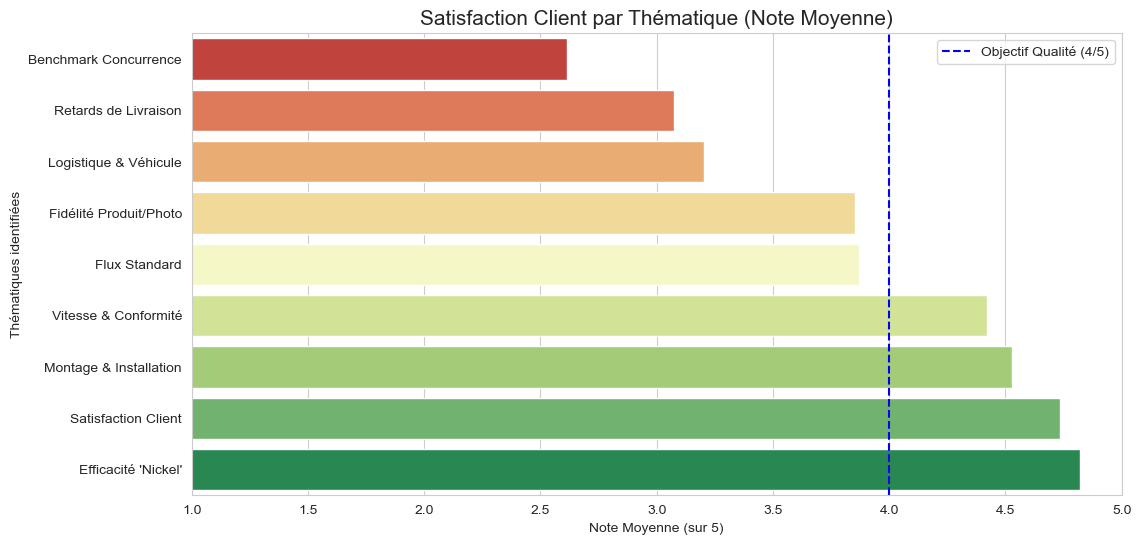

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Création du graphique à bulles (ou barres)
ax = sns.barplot(x='mean', y='topic_label', data=analyse_stats, palette='RdYlGn')

plt.axvline(x=4, color='blue', linestyle='--', label='Objectif Qualité (4/5)')
plt.title('Satisfaction Client par Thématique (Note Moyenne)', fontsize=15)
plt.xlabel('Note Moyenne (sur 5)')
plt.ylabel('Thématiques identifiées')
plt.xlim(1, 5)
plt.legend()

plt.show()

### Sauvegarde à Topics Réduits

In [14]:
# 2. SAUVEGARDE DU MODÈLE RÉDUIT (Très important pour l'app)
# On change de nom pour ne pas confondre avec la version 151 thèmes
topic_model.save("modele_bertopic_reduced", serialization="safetensors", save_ctfidf=True)

# 3. SAUVEGARDE DU DATAFRAME FINAL
# C'est ce fichier qui servira à faire tes graphiques dans Streamlit
df.to_csv('avis_oscaro_9_familles.csv', index=False, sep=';')

print("Fichiers prêts pour la production (9 thèmes) !")

Fichiers prêts pour la production (9 thèmes) !
